## Car Evaluation Prediction Data Science Project

#### Description
In this project, several classical machine learning algorithms were trained and evaluated on the Car Evaluation Dataset, a well-known benchmark dataset containing categorical features describing the purchasing acceptability of a car. After preprocessing the features using one-hot encoding and splitting the data into training and test sets, five different models were tested: SVM, Gaussian Naive Bayes, Gradient Boosting, K-Nearest Neighbors, and Decision Tree.

Dataset url: https://www.kaggle.com/datasets/elikplim/car-evaluation-data-set

In [ ]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression  
from sklearn.tree import DecisionTreeClassifier   
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#### Exploratory Data Analysis

In [ ]:
# Load & Preview the dataset
cars = pd.read_csv('car_evaluation.csv')
cars.head()

,vhigh,vhigh.1,2,2.1,small,low,unacc
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


In [ ]:
# Display dataset information
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   vhigh    1727 non-null   object
 1   vhigh.1  1727 non-null   object
 2   2        1727 non-null   object
 3   2.1      1727 non-null   object
 4   small    1727 non-null   object
 5   low      1727 non-null   object
 6   unacc    1727 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [ ]:
# Check for duplicate entries
cars.duplicated().sum()

np.int64(0)

#### Data Preprocessing

In [24]:
# Data Preprocessing
cars = pd.get_dummies(cars, columns=['vhigh'], prefix='vhigh')
cars = pd.get_dummies(cars, columns=['vhigh.1'], prefix='vhigh.1')
cars = pd.get_dummies(cars, columns=['small'], prefix='small')
cars = pd.get_dummies(cars, columns=['low'], prefix='low')
cars['unacc'] = cars['unacc'].map({'unacc': 0, 'acc': 1, 'good': 2, 'vgood': 3})
cars['unacc'] = cars['unacc'].astype('int8')
cars['unacc'].dtype

KeyError: "None of [Index(['vhigh'], dtype='object')] are in the [columns]"

In [ ]:
# Handle non-numeric data and split the dataset
cars_numeric = cars.apply(pd.to_numeric, errors='coerce')
cars = cars_numeric.dropna().copy()
X = cars.drop('unacc', axis=1)
y = cars['unacc']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((690, 16), (173, 16), (690,), (173,))

#### Train and Evaluate Different Classifiers

In [ ]:
# Train a Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf = rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')
conf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(classification_report(y_test, y_pred))


Accuracy: 0.9769
Confusion Matrix:
[[133   1   0   0]
 [  2  28   0   0]
 [  0   0   5   0]
 [  0   1   0   3]]
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       134
           1       0.93      0.93      0.93        30
           2       1.00      1.00      1.00         5
           3       1.00      0.75      0.86         4

    accuracy                           0.98       173
   macro avg       0.98      0.92      0.94       173
weighted avg       0.98      0.98      0.98       173



<Axes: >

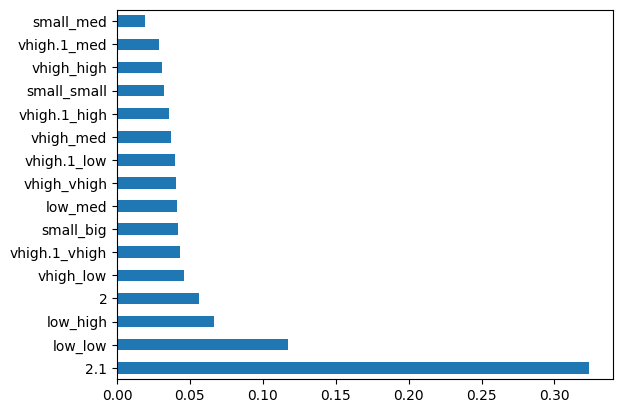

In [ ]:
# Feature Importance from Random Forest
rf.feature_importances_
feature_importances = pd.Series(rf.feature_importances_, index=X.columns)
feature_importances.sort_values(ascending=False).plot(kind='barh')

In [ ]:
# Hyperparameter Tuning for Random Forest using Grid Search
param_grid = {
    'n_estimators' : [100, 200, 500],
    'max_depth' : [None, 10, 20, 30],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features' : ['sqrt', 'log2', None]
}

# Fitting the model
rf = RandomForestClassifier(n_jobs=-1, random_state=9)
grid_search = GridSearchCV(rf, param_grid, cv=3, n_jobs=-1, verbose=2 )

In [ ]:
# Fitting the model 
grid_search.fit(X_train, y_train)
# Getting the best estimator
best_rf = grid_search.best_estimator_
best_rf
best_rf.score(X_test, y_test)
# Calculating and printing Recall Score for the best estimator
y_preds = best_rf.predict(X_test)
print('rf: ', accuracy_score(y_test, y_preds))

Fitting 3 folds for each of 324 candidates, totalling 972 fits
rf:  0.9826589595375722


In [ ]:
# Cross-Validation Scores
cv_scores = cross_val_score(best_rf, X, y, cv=5, scoring='accuracy', n_jobs=-1)
print(f'Cross-Validation Scores: {cv_scores}')
print(f'Mean Cross-Validation Score: {cv_scores.mean():.4f}')


Cross-Validation Scores: [0.76300578 0.86127168 0.82080925 0.89534884 0.85465116]
Mean Cross-Validation Score: 0.8390


In [ ]:
# Train a Logistic Regression model for comparison
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)
accuracy_log = accuracy_score(y_test, y_pred_log)
print(f'Logistic Regression Accuracy: {accuracy_log:.4f}')

Logistic Regression Accuracy: 0.9306


In [ ]:
# Cross-Validation Scores for Logistic Regression
cv_scores = cross_val_score(log_reg, X, y, cv=5, scoring='accuracy', n_jobs=-1)
print(f'Cross-Validation Scores: {cv_scores}')
print(f'Mean Cross-Validation Score: {cv_scores.mean():.4f}')

Cross-Validation Scores: [0.82080925 0.88439306 0.80346821 0.90116279 0.86627907]
Mean Cross-Validation Score: 0.8552


In [ ]:
# Train a Decision Tree Classifier for comparison
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f'Decision Tree Accuracy: {accuracy_dt:.4f}')

Decision Tree Accuracy: 0.9942


In [ ]:
# Cross-Validation Scores for Decision Tree
cv_scores = cross_val_score(dt, X, y, cv=5, scoring='accuracy', n_jobs=-1)
print(f'Cross-Validation Scores: {cv_scores}')
print(f'Mean Cross-Validation Score: {cv_scores.mean():.4f}')

Cross-Validation Scores: [0.82080925 0.86127168 0.76300578 0.89534884 0.85465116]
Mean Cross-Validation Score: 0.8390


#### 🔍 Results Discussion (Three Models Evaluated)

- Three models were evaluated:
  - **Logistic Regression**
  - **Decision Tree**
  - **Random Forest**

#### 🌲 Random Forest Performance
- **Test Accuracy:** 0.9827
- **Cross-Validation Scores:** [0.8208, 0.8613, 0.7630, 0.8953, 0.8547]
- **Mean Cross-Validation Score:** 0.8390
- **Interpretation:**
  - Gap between test accuracy and CV mean suggests slight overfitting.
  - CV scores are consistent, showing reasonable generalization.

#### 📈 Logistic Regression Performance
- **Test Accuracy:** 0.9306
- **Mean Cross-Validation Score:** 0.8517
- **Interpretation:**
  - Results are stable and reliable.
  - Model generalizes well across folds.

#### 🌳 Decision Tree Performance
- **Test Accuracy:** 0.9942
- **Mean Cross-Validation Score:** 0.8390
- **Interpretation:**
  - Very high test accuracy but lower CV mean.
  - Indicates higher sensitivity to training data (overfitting).

#### ✅ Overall Conclusion
- **Random Forest** offers the best balance between accuracy and robustness.
- **Logistic Regression** is stable and reliable.
- **Decision Tree** is highly accurate but more prone to overfitting.
